In [ ]:
import os
from functools import reduce

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from statsmodels.tsa.seasonal import seasonal_decompose

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import numpy as np

data_path = "data"

In [ ]:
dfs = []
for file in os.listdir(data_path):
    if file.endswith(".csv"):
        df = pd.read_csv(os.path.join(data_path, file))
        df['Date'] = pd.to_datetime(df['YYYYMM'], format='%Y%m', errors='coerce')
        df = df.drop(columns=['YYYYMM'])
        df = df.dropna(subset=['Date'])
        dfs.append(df)

In [ ]:
dfs[0] = dfs[0][dfs[0]["MSN"] == "ESRCUUS"]
dfs[0] = dfs[0][["Value", "Date"]].rename(columns={"Value": "Price"})

In [ ]:
dfs[1]["Region"] = dfs[1]["Description"].str.split(", ").str[1]
dfs[1] = dfs[1][["Value", "Date", "Region"]].rename(columns={"Value": "Cooling Degree Days"})

In [ ]:
dfs[2]["Region"] = dfs[2]["Description"].str.split(", ").str[1]
dfs[2] = dfs[2][["Value", "Date", "Region"]].rename(columns={"Value": "Heating Degree Days"})

In [ ]:
dfs[3] = dfs[3][dfs[3]["Description"].str.contains("Total Energy Consumed by the Residential Sector")]
dfs[3] = dfs[3][["Value", "Description", "Date"]].rename(columns={"Value": "Total Energy Consumption"})

In [ ]:
df = dfs[0].merge(dfs[1], on="Date", how="inner").merge(dfs[2], on=["Date", "Region"], how="inner").merge(dfs[3], on="Date", how="inner")

In [ ]:
df.head(15)

,Price,Date,Cooling Degree Days,Region,Heating Degree Days,Total Energy Consumption,Description
0,Not Available,1976-01-01,0,New England,1397,1943.925,Total Energy Consumed by the Residential Sector
1,Not Available,1976-01-01,0,Middle Atlantic,1327,1943.925,Total Energy Consumed by the Residential Sector
2,Not Available,1976-01-01,0,East North Central,1410,1943.925,Total Energy Consumed by the Residential Sector
3,Not Available,1976-01-01,0,West North Central,1387,1943.925,Total Energy Consumed by the Residential Sector
4,Not Available,1976-01-01,11,South Atlantic,779,1943.925,Total Energy Consumed by the Residential Sector
5,Not Available,1976-01-01,2,East South Central,911,1943.925,Total Energy Consumed by the Residential Sector
6,Not Available,1976-01-01,7,West South Central,616,1943.925,Total Energy Consumed by the Residential Sector
7,Not Available,1976-01-01,0,Mountain,1005,1943.925,Total Energy Consumed by the Residential Sector
8,Not Available,1976-01-01,8,Pacific,575,1943.925,Total Energy Consumed by the Residential Sector
9,Not Available,1976-01-01,4,United States,1050,1943.925,Total Energy Consumed by the Residential Sector


In [ ]:
# 1. Renomeamos as colunas longas para as siglas ANTES do pivot
df = df.rename(columns={
    'Cooling Degree Days': 'CDD',
    'Heating Degree Days': 'HDD'
})

# 2. Definimos quais colunas vão identificar nossa "linha única"
colunas_base = ['Date', 'Price', 'Total Energy Consumption']

# 3. Fazemos o pivot (agora usando os nomes curtos 'CDD' e 'HDD')
df_pivotado = df.pivot_table(
    index=colunas_base,
    columns='Region',
    values=['CDD', 'HDD']
)

# 4. Juntamos os dois níveis (isso vai gerar nomes como 'CDD_New England')
df_pivotado.columns = [f"{variavel} {regiao}" for variavel, regiao in df_pivotado.columns]

# 5. Resetamos o índice para transformar a Date e as outras bases de volta em colunas
df_final = df_pivotado.reset_index()

# Visualizando o resultado
df_final.head()

,Date,Price,Total Energy Consumption,CDD East North Central,CDD East South Central,CDD Middle Atlantic,CDD Mountain,CDD New England,CDD Pacific,CDD South Atlantic,...,HDD East North Central,HDD East South Central,HDD Middle Atlantic,HDD Mountain,HDD New England,HDD Pacific,HDD South Atlantic,HDD United States,HDD West North Central,HDD West South Central
0,1976-01-01,Not Available,1943.925,0.0,2.0,0.0,0.0,0.0,8.0,11.0,...,1410.0,911.0,1327.0,1005.0,1397.0,575.0,779.0,1050.0,1387.0,616.0
1,1976-02-01,Not Available,1626.369,0.0,10.0,0.0,3.0,0.0,6.0,22.0,...,886.0,461.0,856.0,732.0,950.0,521.0,416.0,661.0,851.0,269.0
2,1976-03-01,Not Available,1388.038,3.0,29.0,0.0,4.0,0.0,8.0,58.0,...,739.0,350.0,764.0,805.0,896.0,542.0,319.0,593.0,836.0,234.0
3,1976-04-01,Not Available,1112.625,1.0,27.0,0.0,16.0,0.0,10.0,54.0,...,447.0,202.0,435.0,494.0,483.0,438.0,172.0,346.0,380.0,77.0
4,1976-05-01,Not Available,949.961,21.0,59.0,9.0,86.0,1.0,43.0,123.0,...,302.0,130.0,274.0,259.0,307.0,199.0,90.0,206.0,252.0,40.0


In [ ]:
df_final

,Date,Price,Total Energy Consumption,CDD East North Central,CDD East South Central,CDD Middle Atlantic,CDD Mountain,CDD New England,CDD Pacific,CDD South Atlantic,...,HDD East North Central,HDD East South Central,HDD Middle Atlantic,HDD Mountain,HDD New England,HDD Pacific,HDD South Atlantic,HDD United States,HDD West North Central,HDD West South Central
0,1976-01-01,Not Available,1943.925,0.0,2.0,0.0,0.0,0.0,8.0,11.0,...,1410.0,911.0,1327.0,1005.0,1397.0,575.0,779.0,1050.0,1387.0,616.0
1,1976-02-01,Not Available,1626.369,0.0,10.0,0.0,3.0,0.0,6.0,22.0,...,886.0,461.0,856.0,732.0,950.0,521.0,416.0,661.0,851.0,269.0
2,1976-03-01,Not Available,1388.038,3.0,29.0,0.0,4.0,0.0,8.0,58.0,...,739.0,350.0,764.0,805.0,896.0,542.0,319.0,593.0,836.0,234.0
3,1976-04-01,Not Available,1112.625,1.0,27.0,0.0,16.0,0.0,10.0,54.0,...,447.0,202.0,435.0,494.0,483.0,438.0,172.0,346.0,380.0,77.0
4,1976-05-01,Not Available,949.961,21.0,59.0,9.0,86.0,1.0,43.0,123.0,...,302.0,130.0,274.0,259.0,307.0,199.0,90.0,206.0,252.0,40.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
598,2025-11-01,17.78,1490.361,0.0,8.0,0.0,19.0,0.0,16.0,50.0,...,742.0,391.0,688.0,484.0,757.0,338.0,305.0,464.0,704.0,146.0
599,2025-12-01,17.24,2144.289,0.0,2.0,0.0,3.0,0.0,13.0,46.0,...,1188.0,672.0,1108.0,645.0,1174.0,445.0,531.0,748.0,1179.0,366.0
600,2026-01-01,17.45,2444.27,0.0,4.0,0.0,3.0,0.0,12.0,28.0,...,1368.0,826.0,1242.0,800.0,1290.0,487.0,636.0,876.0,1355.0,532.0
601,2026-02-01,17.65,1954.105,0.0,6.0,0.0,14.0,0.0,10.0,22.0,...,995.0,562.0,1074.0,547.0,1162.0,402.0,503.0,653.0,878.0,232.0


In [ ]:
df_final['Date'] = pd.to_datetime(df_final['Date'])
df_final.set_index('Date', inplace=True)

# 2. Tratar a coluna 'Price' que contém "Not Available"
# O coerce transforma strings inválidas em NaN (Not a Number)
df_final['Price'] = pd.to_numeric(df_final['Price'], errors='coerce')

# Como séries temporais precisam de continuidade, vamos preencher os NaNs iniciais.
# O método 'bfill' (backward fill) usa o primeiro valor válido para preencher o passado,
# mas você pode optar por imputar a média histórica ou remover essas colunas/linhas futuramente.
df_final['Price'] = df_final['Price'].bfill()

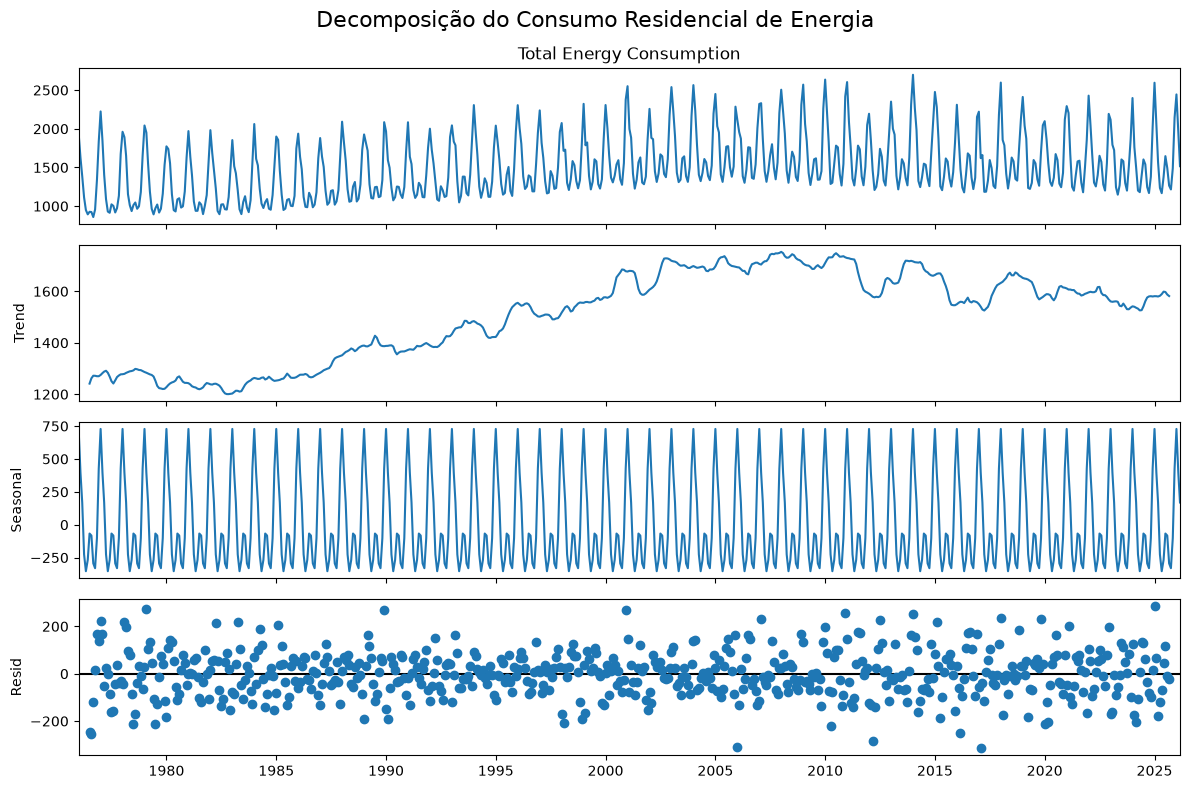

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Decomposição da série temporal do Consumo Total
# Extrapolamos que a sazonalidade é anual (12 meses)
resultado_decomposicao = seasonal_decompose(df_final['Total Energy Consumption'], model='additive', period=12)

# Plotando os componentes (Observado, Tendência, Sazonalidade e Ruído)
plt.rcParams.update({'figure.figsize': (12, 8)})
resultado_decomposicao.plot()
plt.suptitle('Decomposição do Consumo Residencial de Energia', fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
# Criando features de atraso (lags) para o alvo e para o preço
# Lag 1 = Mês anterior, Lag 12 = Mesmo mês no ano anterior
df_final['Target_Lag1'] = df_final['Total Energy Consumption'].shift(1)
df_final['Target_Lag12'] = df_final['Total Energy Consumption'].shift(12)

# Criando features de mês para ajudar o modelo com a sazonalidade
df_final['Month'] = df_final.index.month

# Remover as linhas que ficaram com NaN devido ao shift(12)
df_ml = df_final.dropna().copy()

Random Forest - RMSE: 91.37 | MAE: 70.81


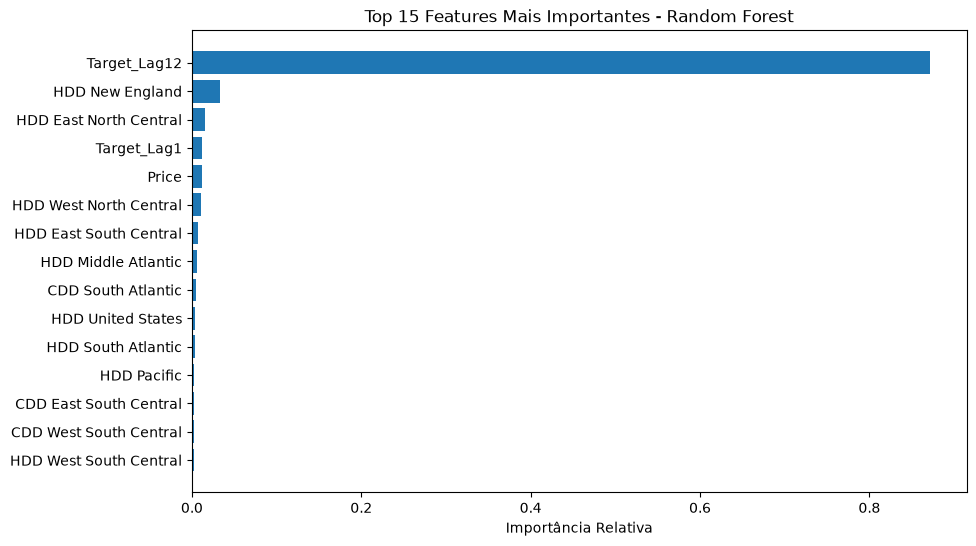

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Separando X (features) e y (target)
target_col = 'Total Energy Consumption'
X = df_ml.drop(columns=[target_col])
y = df_ml[target_col]

# Divisão Treino/Teste sem embaralhar (shuffle=False), pois é uma série temporal
train_size = int(len(df_ml) * 0.8) # 80% treino, 20% teste
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

# Instanciando e treinando o Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Avaliação simples
y_pred = rf_model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
print(f"Random Forest - RMSE: {rmse:.2f} | MAE: {mae:.2f}")

# Plot da Importância das Features
importances = rf_model.feature_importances_
indices = np.argsort(importances)[-15:] # Pegando as 15 variáveis mais importantes

plt.figure(figsize=(10, 6))
plt.title("Top 15 Features Mais Importantes - Random Forest")
plt.barh(range(len(indices)), importances[indices], align="center")
plt.yticks(range(len(indices)), [X.columns[i] for i in indices])
plt.xlabel("Importância Relativa")
plt.show()

Random Forest (Sem Tempo) - RMSE: 101.66 | MAE: 75.37


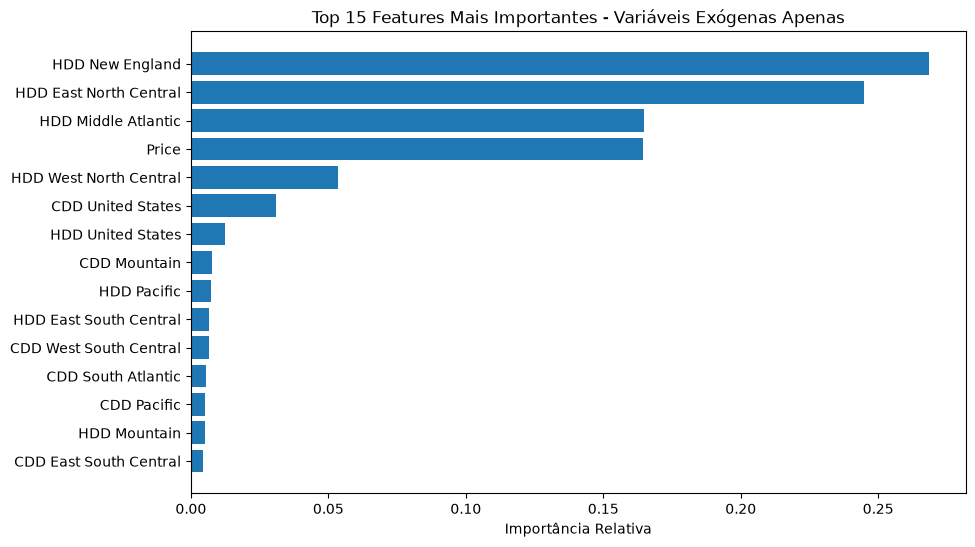

In [ ]:
df_cross = df_final.copy()

# Se a data for o índice, nós a removemos (reset_index com drop=True)
if df_cross.index.name == 'Date':
    df_cross = df_cross.reset_index(drop=True)
# Se a data ainda for uma coluna normal, nós a deletamos
elif 'Date' in df_cross.columns:
    df_cross = df_cross.drop(columns=['Date'])

# 2. Garantir que variáveis temporais (se criadas antes) sejam removidas
colunas_temporais = ['Target_Lag1', 'Target_Lag12', 'Month']
df_cross = df_cross.drop(columns=[c for c in colunas_temporais if c in df_cross.columns])

# Remover eventuais valores nulos (NaN)
df_cross = df_cross.dropna()

# 3. Separar X (features) e y (target)
target_col = 'Total Energy Consumption'
X = df_cross.drop(columns=[target_col])
y = df_cross[target_col]

# 4. Divisão Treino/Teste COM embaralhamento (shuffle=True)
# Como não é série temporal, o shuffle garante que o modelo veja amostras de todos os cenários
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

# 5. Instanciando e treinando o Random Forest
rf_model_cross = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model_cross.fit(X_train, y_train)

# 6. Avaliação
y_pred = rf_model_cross.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
print(f"Random Forest (Sem Tempo) - RMSE: {rmse:.2f} | MAE: {mae:.2f}")

# 7. Plot da Importância das Features
importances = rf_model_cross.feature_importances_
indices = np.argsort(importances)[-15:] # Top 15 variáveis

plt.figure(figsize=(10, 6))
plt.title("Top 15 Features Mais Importantes - Variáveis Exógenas Apenas")
plt.barh(range(len(indices)), importances[indices], align="center")
plt.yticks(range(len(indices)), [X.columns[i] for i in indices])
plt.xlabel("Importância Relativa")
plt.show()

In [ ]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import numpy as np

# Assumindo que df_ml já possui as features temporais (Target_Lag1, Target_Lag12, Month)
target_col = 'Total Energy Consumption'
X_time = df_ml.drop(columns=[target_col])
y_time = df_ml[target_col]

# Divisão cronológica (sem shuffle)
train_size = int(len(df_ml) * 0.8)
X_train_t, X_test_t = X_time.iloc[:train_size], X_time.iloc[train_size:]
y_train_t, y_test_t = y_time.iloc[:train_size], y_time.iloc[train_size:]

# Instanciando o XGBoost
# Dica: tree_method='hist' constrói histogramas e é consideravelmente mais rápido em CPUs modernas e arquiteturas ARM
xgb_time_model = xgb.XGBRegressor(
    n_estimators=100, 
    learning_rate=0.1, 
    max_depth=5, 
    tree_method='hist',
    random_state=42
)

# Treinamento
xgb_time_model.fit(X_train_t, y_train_t)

# Avaliação
y_pred_t = xgb_time_model.predict(X_test_t)
rmse_t = np.sqrt(mean_squared_error(y_test_t, y_pred_t))
mae_t = mean_absolute_error(y_test_t, y_pred_t)
print(f"XGBoost (Temporal) - RMSE: {rmse_t:.2f} | MAE: {mae_t:.2f}")

# Plot da Importância (Gain)
xgb.plot_importance(xgb_time_model, importance_type='gain', max_num_features=15, title='XGBoost Temporal - Importância (Gain)')
plt.show()

ModuleNotFoundError: No module named 'xgboost'